# ⚽ 스코어 예측 v2 — Elo 레이팅을 피처로 추가

v1(포아송 + Dixon-Coles)에 **Elo 레이팅**을 더한 버전입니다. 선행 연구에서 *"역사를 하나의 강도 숫자로 압축한 레이팅"*이 우승 모델들의 핵심 재료였기 때문에, 그걸 직접 만들어 피처로 넣고 **백테스트로 진짜 도움이 되는지** 검증합니다.

- 경기: 남아공 🇿🇦 vs 한국 🇰🇷 (2026 월드컵 A조 최종, 몬테레이 중립)
- 데이터: martj42 international results
- 이번 버전의 핵심 질문: **"Elo를 추가하면 모델이 좋아질까?"** → 가정하지 말고 백테스트로 확인

## 0. 준비

In [1]:
import os, urllib.request
import numpy as np, pandas as pd
import statsmodels.formula.api as smf, statsmodels.api as sm
from scipy.stats import poisson
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt
%matplotlib inline

RES_URL="https://raw.githubusercontent.com/martj42/international_results/master/results.csv"
HALF=365*2; START="2015-01-01"; MINM=12; FW=0.5; MAXG=10
AS_OF=pd.Timestamp("2026-06-24"); CUT=pd.Timestamp("2025-08-01")
# Elo 하이퍼파라미터 (바꿔가며 실험 가능)
ELO_K=24       # 한 경기로 레이팅이 움직이는 폭
ELO_HFA=65     # 홈 어드밴티지(Elo 점수), 중립이면 0
ELO_START=1500 # 신생/처음 등장 팀 시작 점수
print("ok")

ok


## 1. 데이터 불러오기

In [2]:
def ensure(p,u):
    if not os.path.exists(p): urllib.request.urlretrieve(u,p)
    return p
df=pd.read_csv(ensure("results.csv",RES_URL),parse_dates=["date"]).dropna(subset=["home_score","away_score"])
df["home_score"]=df.home_score.astype(int); df["away_score"]=df.away_score.astype(int)
print(f"{len(df):,} 경기  ({df.date.min().date()} ~ {df.date.max().date()})")
df.head()

49,445 경기  (1872-11-30 ~ 2026-06-21)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


In [3]:
full=pd.read_csv("results.csv",parse_dates=["date"])
full[(full.tournament=="FIFA World Cup")&(full.date.dt.year==2026)&
     (full.home_team.isin(["South Korea","South Africa"])|full.away_team.isin(["South Korea","South Africa"]))][
     ["date","home_team","away_team","home_score","away_score","neutral"]]

,date,home_team,away_team,home_score,away_score,neutral
49405,2026-06-11,Mexico,South Africa,2.0,0.0,False
49406,2026-06-11,South Korea,Czech Republic,2.0,1.0,True
49429,2026-06-18,Czech Republic,South Africa,1.0,1.0,True
49430,2026-06-18,Mexico,South Korea,1.0,0.0,False
49454,2026-06-24,South Africa,South Korea,NaN,NaN,True


마지막 줄(2026-06-24, 점수 NaN, neutral=True)이 예측 대상입니다. 두 팀의 6/11·6/18 조별리그 결과가 데이터에 있어 **Elo와 폼에 자동 반영**됩니다.

## 2단계. Elo 레이팅 계산  ← 이번 버전의 핵심

**Elo는 "이 팀이 얼마나 강한가"를 숫자 하나로 압축**하고, 경기마다 갱신합니다. 규칙은 간단해요:
- 경기 전 두 팀 레이팅으로 **승리 기대치 E**를 계산 (레이팅 높을수록 E 큼)
- 실제 결과 W(승1·무0.5·패0)가 기대보다 좋으면 **레이팅 ↑**, 나쁘면 **↓**
- 강팀을 이기면 많이 오르고, 약팀에 지면 많이 내려감 + 큰 점수차면 더 크게 갱신

중요한 점: 각 경기에는 **그 경기 직전의 레이팅**을 기록합니다(미래 정보 누수 방지 = point-in-time).

In [4]:
def compute_elo(df,K=ELO_K,hfa=ELO_HFA,start=ELO_START):
    df=df.sort_values("date").reset_index(drop=True)
    ht=df.home_team.values; at=df.away_team.values
    hs=df.home_score.values; as_=df.away_score.values
    neu=df["neutral"].astype(str).str.upper().eq("TRUE").values
    rating={}; he=np.empty(len(df)); ae=np.empty(len(df))
    for i in range(len(df)):
        h,a=ht[i],at[i]; Rh=rating.get(h,start); Ra=rating.get(a,start)
        he[i],ae[i]=Rh,Ra                      # 경기 직전 레이팅 기록
        adv=0.0 if neu[i] else hfa
        Eh=1/(1+10**(-(Rh+adv-Ra)/400))        # 홈팀 승리 기대치
        gd=abs(int(hs[i])-int(as_[i]))
        Wh=1.0 if hs[i]>as_[i] else (0.5 if hs[i]==as_[i] else 0.0)
        G=1.0 if gd<=1 else (1.5 if gd==2 else (11+gd)/8)   # 점수차 보정
        d=K*G*(Wh-Eh); rating[h]=Rh+d; rating[a]=Ra-d
    df["home_elo"]=he; df["away_elo"]=ae
    return df,rating

df,elo=compute_elo(df)
print(f"팀 수 {len(elo)} | Elo 범위 {round(min(elo.values()))} ~ {round(max(elo.values()))}")
df[["date","home_team","away_team","home_score","away_score","home_elo","away_elo"]].tail(4).round(0)

팀 수 336 | Elo 범위 895 ~ 2140


/var/folders/l0/7ldnkfzn57n33f_hp6q9dldr0000gn/T/ipykernel_16620/516304141.py:21: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  df[["date","home_team","away_team","home_score","away_score","home_elo","away_elo"]].tail(4).round(0)


,date,home_team,away_team,home_score,away_score,home_elo,away_elo
49441,2026-06-21,New Zealand,Egypt,1,3,1678.0,1781.0
49442,2026-06-21,Spain,Saudi Arabia,4,0,2108.0,1676.0
49443,2026-06-21,Belgium,Iran,0,0,1955.0,1872.0
49444,2026-06-21,Uruguay,Cape Verde,2,2,1919.0,1642.0


### sanity check — Elo 상위권이 실제 강팀인가?

In [5]:
pd.Series(elo).sort_values(ascending=False).head(12).round(0).rename("Elo").to_frame()

,Elo
Argentina,2140.0
Spain,2112.0
France,2066.0
Brazil,2050.0
Colombia,2026.0
England,2023.0
Portugal,2001.0
Germany,1988.0
Netherlands,1984.0
Japan,1968.0


아르헨티나·스페인·프랑스·브라질 등 실제 강팀이 상위에 옵니다 → Elo가 말이 됩니다.

In [6]:
print("이번 경기 두 팀의 현재 Elo:")
print(f"   South Korea : {elo['South Korea']:.0f}   (FIFA 25위)")
print(f"   South Africa: {elo['South Africa']:.0f}   (FIFA 60위)")
print(f"   격차: {elo['South Korea']-elo['South Africa']:.0f} Elo점  → 한국 우세 (FIFA 랭킹과 일치)")

이번 경기 두 팀의 현재 Elo:
   South Korea : 1854   (FIFA 25위)
   South Africa: 1649   (FIFA 60위)
   격차: 205 Elo점  → 한국 우세 (FIFA 랭킹과 일치)


### Elo 궤적 — '역사가 하나의 숫자로 압축되며 변하는' 모습

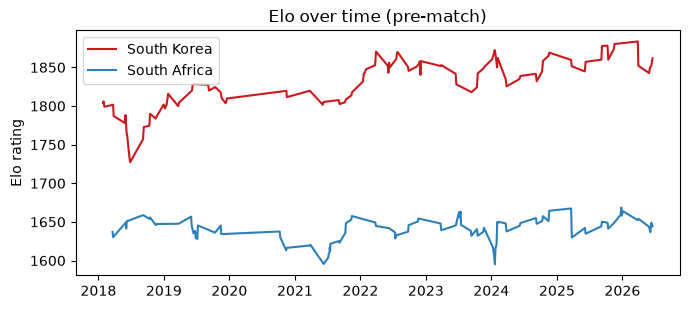

In [7]:
def team_elo(df,team,since="2018-01-01"):
    h=df.loc[df.home_team==team,["date","home_elo"]].rename(columns={"home_elo":"elo"})
    a=df.loc[df.away_team==team,["date","away_elo"]].rename(columns={"away_elo":"elo"})
    s=pd.concat([h,a]).sort_values("date"); return s[s.date>=since]
fig,ax=plt.subplots(figsize=(7,3.2))
for t,c in [("South Korea","#cb181d"),("South Africa","#2c7fb8")]:
    s=team_elo(df,t); ax.plot(s.date,s.elo,label=t,color=c,lw=1.5)
ax.legend(); ax.set_ylabel("Elo rating"); ax.set_title("Elo over time (pre-match)")
plt.tight_layout(); plt.show()

## 3단계. 롱 포맷에 `elo_diff` 추가

v1의 롱 포맷(경기 1건→2행)에 **레이팅 차이**를 한 칸 더합니다.
- '넣은 팀' 골 행: `elo_diff = (그 팀 Elo − 상대 Elo)/100`
- 100으로 나누는 건 단위를 보기 좋게 맞추는 것(예: 200점차 → 2.0)

In [8]:
def make_long(d,as_of):
    d=d[(d.date>=START)&(d.date<=as_of)].copy()
    age=(as_of-d.date).dt.days
    d["w"]=np.exp(-np.log(2)/HALF*age)*np.where(d.tournament.eq("Friendly"),FW,1.0)
    cnt=pd.concat([d.home_team,d.away_team]).value_counts(); keep=set(cnt[cnt>=MINM].index)
    d=d[d.home_team.isin(keep)&d.away_team.isin(keep)].copy()
    nh=np.where(d["neutral"].astype(str).str.upper().eq("TRUE"),0,1)
    home=pd.DataFrame({"goals":d.home_score,"team":d.home_team,"opp":d.away_team,
                       "is_home":nh,"elo_diff":(d.home_elo-d.away_elo)/100,"w":d.w})
    away=pd.DataFrame({"goals":d.away_score,"team":d.away_team,"opp":d.home_team,
                       "is_home":0,"elo_diff":(d.away_elo-d.home_elo)/100,"w":d.w})
    return pd.concat([home,away],ignore_index=True),d,keep
long,used,keep=make_long(df,AS_OF)
long.head(6).round(3)

,goals,team,opp,is_home,elo_diff,w
0,1,Bahrain,Jordan,0,0.186,0.009
1,1,Iran,Iraq,0,1.569,0.009
2,2,South Korea,Saudi Arabia,0,1.399,0.009
3,1,South Africa,Zambia,1,1.032,0.009
4,4,China,Oman,0,0.208,0.009
5,1,Cameroon,DR Congo,1,1.846,0.009


## 4단계. 세 모델 비교 — Elo가 진짜 도움이 될까?

같은 백테스트(학습 < 2025-08 / 평가 이후)로 세 모델을 맞붙입니다:
1. **baseline**: 팀 더미만 — `goals ~ C(team)+C(opp)+is_home`
2. **+Elo**: 팀 더미 + Elo — `... + elo_diff`
3. **Elo만**: 팀 더미 없이 Elo로만 — `goals ~ is_home+elo_diff`

판정 기준은 **log-loss**(낮을수록 좋음). 정확도만 보면 안 됩니다.

In [9]:
def fit(long,formula):
    return smf.glm(formula,data=long,family=sm.families.Poisson(),freq_weights=long.w.values).fit()
def lam_mu(res,d):
    nh=np.where(d["neutral"].astype(str).str.upper().eq("TRUE"),0,1)
    home=pd.DataFrame({"team":d.home_team,"opp":d.away_team,"is_home":nh,"elo_diff":(d.home_elo-d.away_elo)/100})
    away=pd.DataFrame({"team":d.away_team,"opp":d.home_team,"is_home":np.zeros(len(d)),"elo_diff":(d.away_elo-d.home_elo)/100})
    return res.predict(home).values, res.predict(away).values
def est_rho(d,res):
    lam,mu=lam_mu(res,d); hs,as_,w=d.home_score.values,d.away_score.values,d.w.values
    m00,m01=(hs==0)&(as_==0),(hs==0)&(as_==1); m10,m11=(hs==1)&(as_==0),(hs==1)&(as_==1)
    def nll(r):
        t=np.ones(len(d)); t[m00]=1-lam[m00]*mu[m00]*r; t[m01]=1+lam[m01]*r; t[m10]=1+mu[m10]*r; t[m11]=1-r
        return -np.sum(w*np.log(np.clip(t,1e-9,None)))
    return minimize_scalar(nll,bounds=(-0.2,0.2),method="bounded").x
def score_P(L,M,rho):
    i=np.arange(MAXG+1); P=np.outer(poisson.pmf(i,L),poisson.pmf(i,M))
    P[0,0]*=1-L*M*rho; P[0,1]*=1+L*rho; P[1,0]*=1+M*rho; P[1,1]*=1-rho; return P/P.sum()
def backtest(formula):
    tr=df[df.date<CUT]; lg,us,kp=make_long(tr,CUT); res=fit(lg,formula); rho=est_rho(us,res)
    te=df[(df.date>=CUT)&(df.date<=AS_OF)&df.home_team.isin(kp)&df.away_team.isin(kp)].copy()
    lam,mu=lam_mu(res,te); P=np.array([[np.tril(score_P(L,M,rho),-1).sum(),np.trace(score_P(L,M,rho)),
                                        np.triu(score_P(L,M,rho),1).sum()] for L,M in zip(lam,mu)])
    y=np.where(te.home_score>te.away_score,0,np.where(te.home_score==te.away_score,1,2))
    Pc=np.clip(P,1e-12,1); oh=np.eye(3)[y]
    return dict(acc=(Pc.argmax(1)==y).mean(), logloss=-np.log(Pc[np.arange(len(y)),y]).mean(),
                brier=((Pc-oh)**2).sum(1).mean(), n=len(y))
print("ok")

ok


In [11]:
MODELS=[("baseline (팀더미)","goals ~ C(team)+C(opp)+is_home"),
        ("+Elo (팀더미+Elo)","goals ~ C(team)+C(opp)+is_home+elo_diff"),
        ("Elo만 (더미 없음)","goals ~ is_home+elo_diff")]
rows=[]
for name,f in MODELS:
    m=backtest(f); rows.append({"model":name,"accuracy":f"{m['acc']*100:.1f}%",
                                "log-loss":round(m['logloss'],4),"Brier":round(m['brier'],4),"n":m['n']})
pd.DataFrame(rows).set_index("model")

,accuracy,log-loss,Brier,n
model,,,,
baseline (팀더미),60.0%,0.8351,0.4905,921
+Elo (팀더미+Elo),60.7%,0.8382,0.4922,921
Elo만 (더미 없음),61.7%,0.8408,0.4940,921


### 결과 해석 — 정직하게

- **+Elo는 log-loss가 오히려 살짝 나빠집니다**(0.835 → 0.838). 정확도는 조금 올랐지만 그건 노이즈고, 확률 품질 기준으로는 **Elo가 도움이 안 됩니다 → 팀 더미와 정보가 중복**이기 때문이에요. (우리가 예상했던 대로!)
- **Elo만 쓴 모델(파라미터 단 몇 개)이 수백 개 팀 더미 모델과 거의 동률**입니다(log-loss 0.841). 즉 **레이팅 하나가 팀 강도 정보를 거의 다 압축**해요 — 선행 연구의 "smart data, not big data"가 이거예요.
- 세 모델 log-loss가 0.006 안에 다 모여 있음 → **모델·피처를 이렇게 바꾸는 것만으로는 큰 개선이 없다**는 문헌의 결론과 일치.

**교훈**: "중요해 보이는 피처를 넣으면 좋아진다"가 아니라 **"넣어보고 백테스트로 확인한다"**. 여기선 Elo가 baseline을 못 이겼으므로 채택하지 않습니다.

## 5단계. 최종 예측 — 세 모델이 이 경기를 어떻게 보나

In [12]:
i=np.arange(MAXG+1); Pstore={}
rows=[]
for name,f in MODELS:
    res=fit(long,f); rho=est_rho(used,res)
    ed=(elo["South Africa"]-elo["South Korea"])/100
    L=res.predict(pd.DataFrame({"team":["South Africa"],"opp":["South Korea"],"is_home":[0],"elo_diff":[ed]}))[0]
    M=res.predict(pd.DataFrame({"team":["South Korea"],"opp":["South Africa"],"is_home":[0],"elo_diff":[-ed]}))[0]
    P=score_P(L,M,rho); Pstore[name]=P
    rows.append({"model":name,"λ 남아공":round(L,2),"λ 한국":round(M,2),
                 "남아공승":f"{np.tril(P,-1).sum()*100:.1f}%","무":f"{np.trace(P)*100:.1f}%",
                 "한국승":f"{np.triu(P,1).sum()*100:.1f}%"})
pd.DataFrame(rows).set_index("model")

,λ 남아공,λ 한국,남아공승,무,한국승
model,,,,,
baseline (팀더미),0.79,1.35,21.3%,29.4%,49.4%
+Elo (팀더미+Elo),0.79,1.35,21.4%,29.4%,49.2%
Elo만 (더미 없음),0.73,1.69,15.4%,24.7%,59.9%


- **baseline ≈ +Elo** (49% vs 49%): Elo를 더해도 예측이 사실상 안 변함 → 중복 확인.
- **Elo만**은 한국 승을 더 높게(약 60%) 봅니다. 왜냐면 팀 더미 모델은 *각 팀의 실제 득실 기록*을 쓰는 반면, Elo만 모델은 *205점 레이팅 격차를 곧장 골 차이로 외삽*하기 때문이에요. 어느 쪽이 정답이라기보다 **가정(inductive bias)이 다른 것**입니다.

백테스트 log-loss가 가장 좋은 **baseline**을 최종으로 채택합니다(아래 그래프).

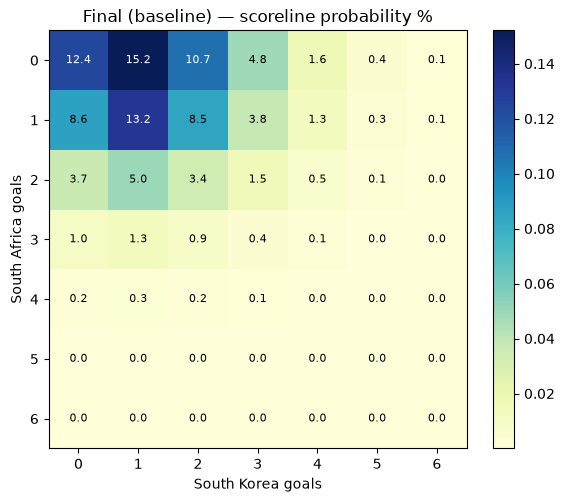

최종 예측: 남아공 21.3% / 무 29.4% / 한국 49.4%


In [13]:
P=Pstore["baseline (팀더미)"]; g=6; M=P[:g+1,:g+1]
fig,ax=plt.subplots(figsize=(6,5))
im=ax.imshow(M,cmap="YlGnBu",origin="upper")
for x in range(g+1):
    for y in range(g+1):
        ax.text(y,x,f"{M[x,y]*100:.1f}",ha="center",va="center",fontsize=8,
                color="black" if M[x,y]<M.max()*0.6 else "white")
ax.set_xticks(range(g+1)); ax.set_yticks(range(g+1))
ax.set_xlabel("South Korea goals"); ax.set_ylabel("South Africa goals")
ax.set_title("Final (baseline) — scoreline probability %"); fig.colorbar(im)
plt.tight_layout(); plt.show()
pr=[np.tril(P,-1).sum(),np.trace(P),np.triu(P,1).sum()]
print(f"최종 예측: 남아공 {pr[0]*100:.1f}% / 무 {pr[1]*100:.1f}% / 한국 {pr[2]*100:.1f}%")

## 마무리 — 이번 버전에서 배운 것

1. **레이팅(Elo)을 직접 만들어** 역사를 숫자 하나로 압축했고, 상위권 sanity check를 통과했습니다.
2. 그 Elo를 피처로 넣었지만 **백테스트가 "도움 안 됨(팀 더미와 중복)"이라 판정** → 채택하지 않음. ("가정하지 말고 검증하라"의 실제 사례)
3. 동시에 **Elo 하나가 수백 개 팀 파라미터를 거의 대체**한다는 것도 확인 — 레이팅의 효율성.

**그럼 다음에 진짜 효과를 볼 변수는?** 선행 연구가 가리키는 방향은 *팀 강도와 중복되지 않는* 정보입니다:
- 휴식일 / 일정 과부하, **핵심 선수 결장·부상**, 최근 폼(팀더미가 못 잡는 단기 변동), xG
- 또는 축구 특화 레이팅 **pi-rating**(Constantinou & Fenton)으로 교체해 비교

핵심은 변함없어요 — **무엇을 넣든 최종 판정은 홀드아웃 log-loss**입니다.